In [1]:
# ANÁLISIS EXPLORATORIO DE DATOS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("retail_customer_segmentation.csv")

# Valores faltantes ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, '% Faltantes': missing_pct})
print(missing_df[missing_df['Faltantes'] > 0])

                       Faltantes  % Faltantes
annual_income               3075         6.15
avg_monthly_spend           2520         5.04
purchase_frequency          1979         3.96
discount_usage_rate         2549         5.10
return_rate                 2487         4.97
browsing_time_minutes       3934         7.87
support_interactions        1988         3.98


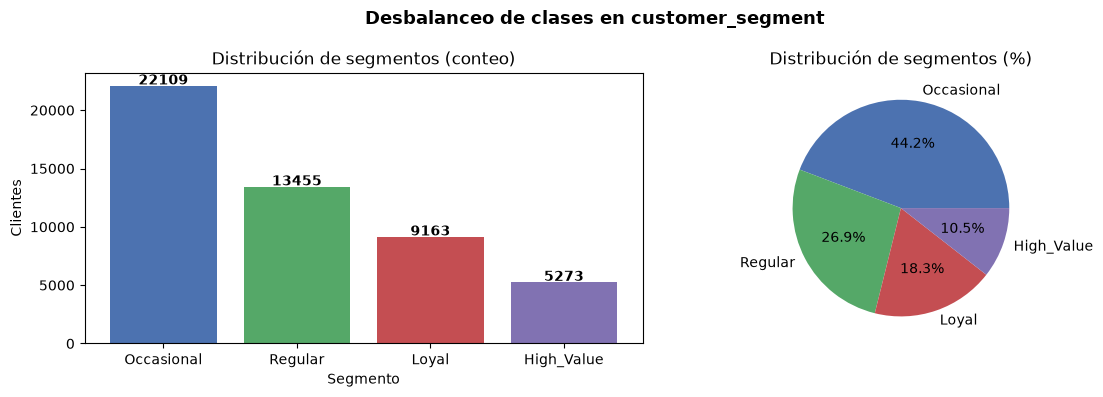

customer_segment
Occasional    44.22
Regular       26.91
Loyal         18.33
High_Value    10.55
Name: count, dtype: float64


In [2]:
# Distribución
seg_counts = df['customer_segment'].value_counts()
seg_pct = (seg_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(seg_counts.index, seg_counts.values, color=['#4C72B0','#55A868','#C44E52','#8172B2'])
axes[0].set_title('Distribución de segmentos (conteo)')
axes[0].set_xlabel('Segmento')
axes[0].set_ylabel('Clientes')
for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(seg_pct, labels=seg_pct.index, autopct='%1.1f%%',
            colors=['#4C72B0','#55A868','#C44E52','#8172B2'])
axes[1].set_title('Distribución de segmentos (%)')

plt.suptitle('Desbalanceo de clases en customer_segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(seg_pct)

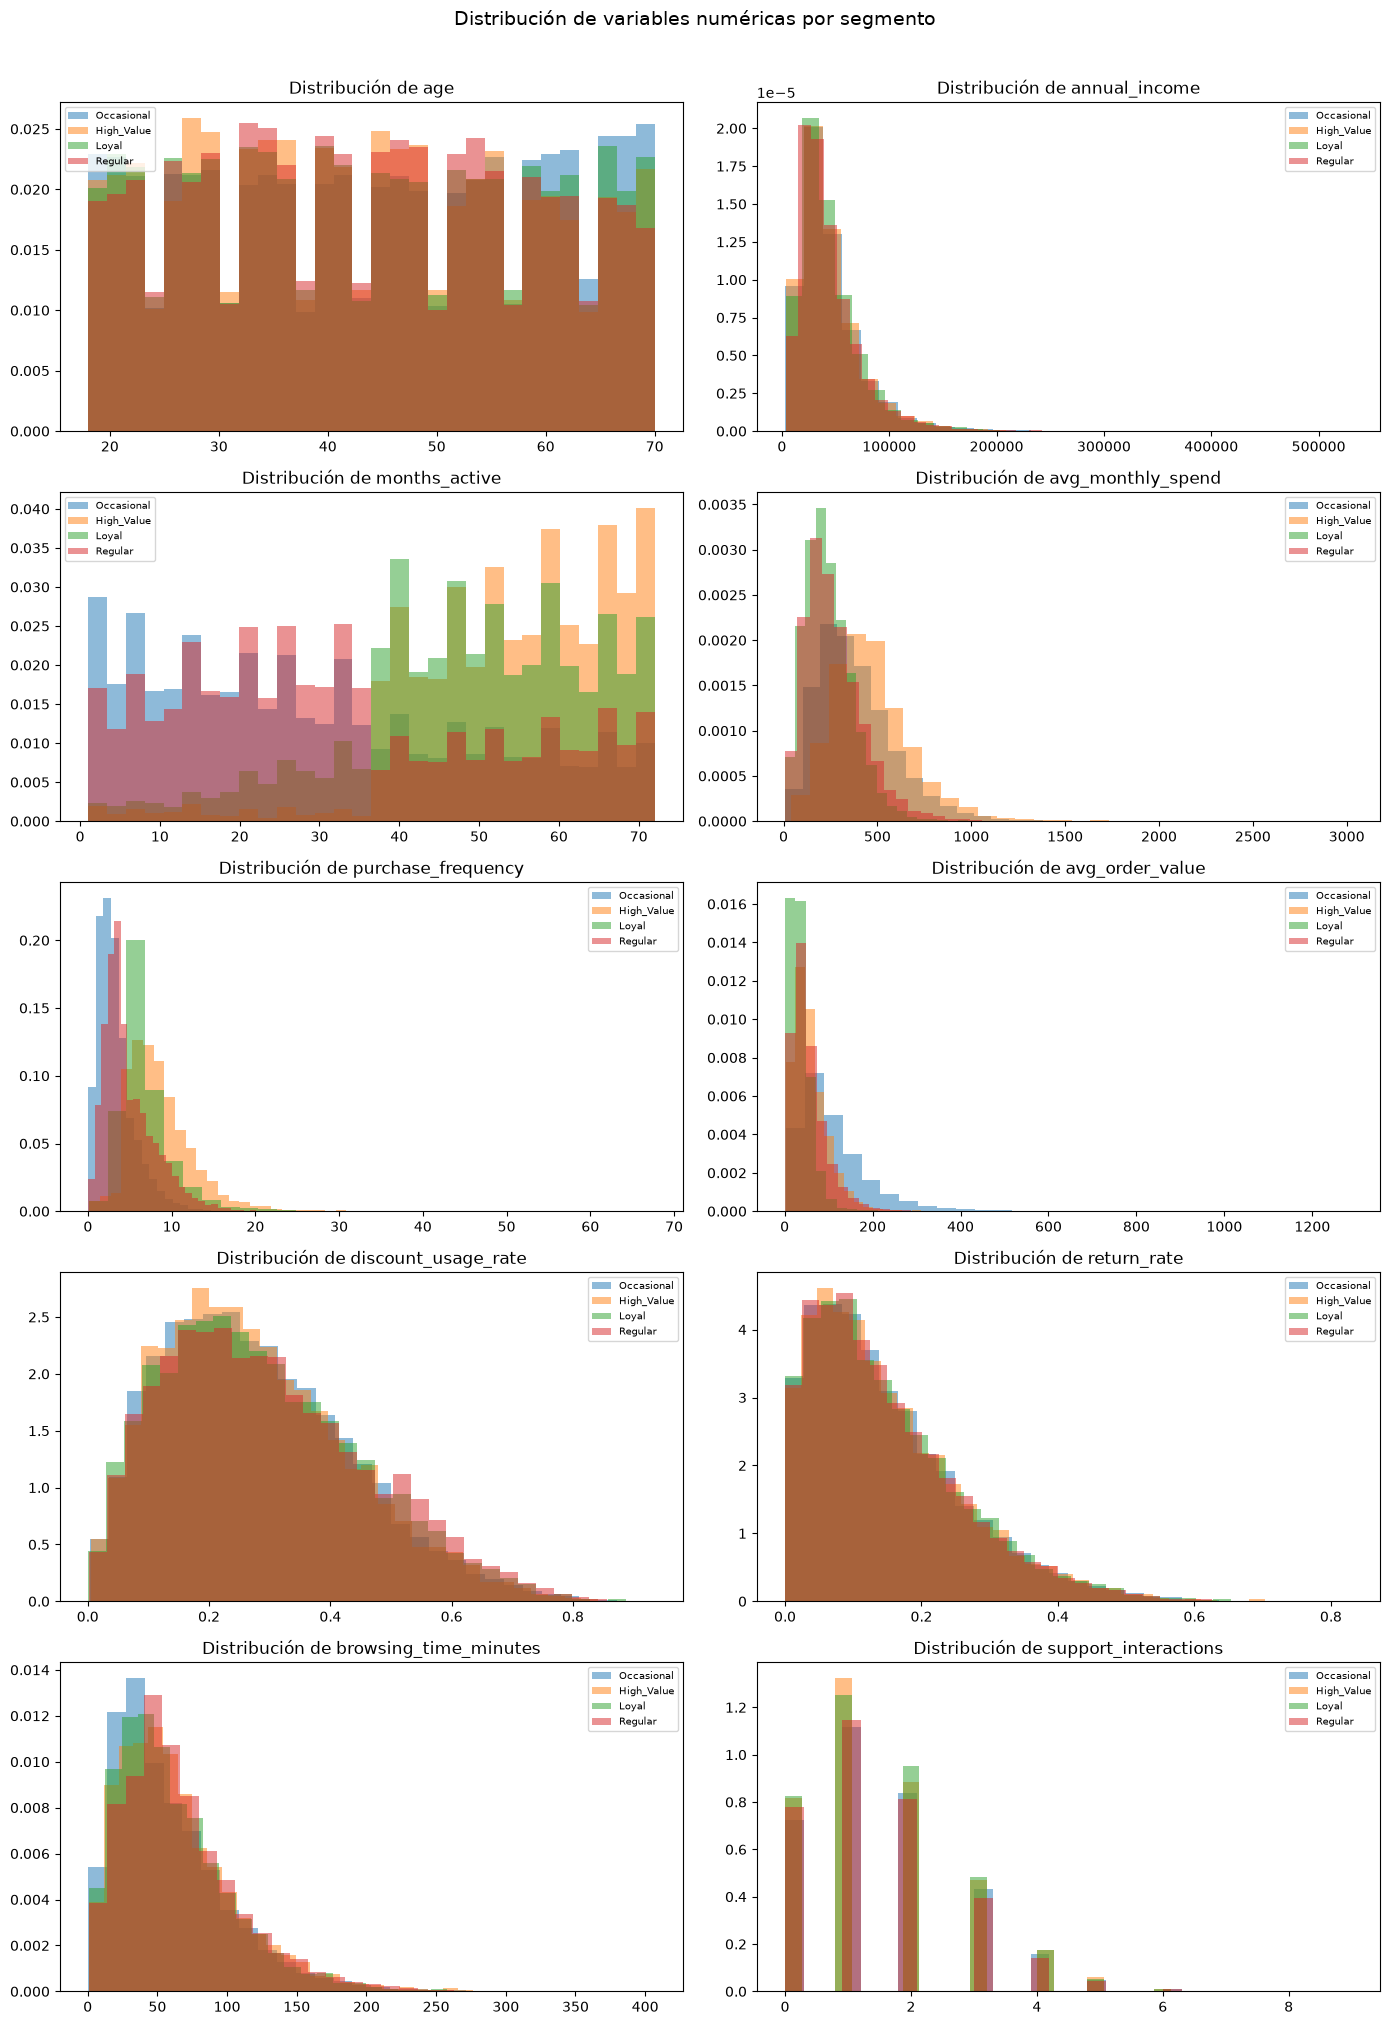

In [3]:
# Distribución de variables numéricas por segmento
num_cols = ['age', 'annual_income', 'months_active', 'avg_monthly_spend',
            'purchase_frequency', 'avg_order_value', 'discount_usage_rate',
            'return_rate', 'browsing_time_minutes', 'support_interactions']

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for seg in df['customer_segment'].unique():
        subset = df[df['customer_segment'] == seg][col].dropna()
        axes[i].hist(subset, alpha=0.5, label=seg, bins=30, density=True)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].legend(fontsize=7)

plt.suptitle('Distribución de variables numéricas por segmento', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

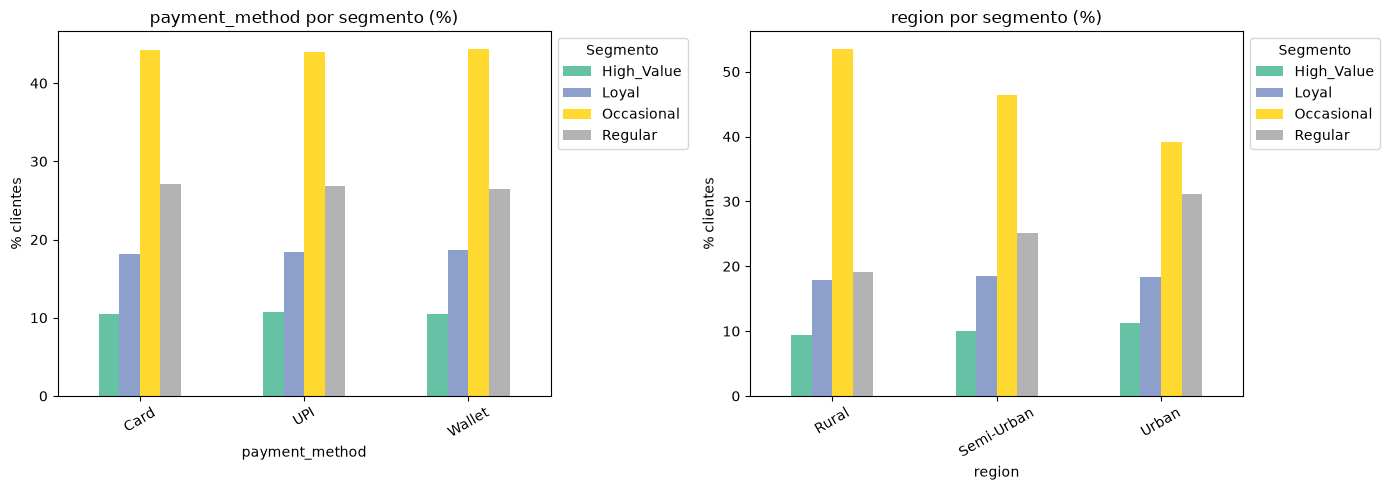

In [4]:
# Variables categóricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['payment_method', 'region']):
    ct = pd.crosstab(df[col], df['customer_segment'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, colormap='Set2')
    ax.set_title(f'{col} por segmento (%)')
    ax.set_xlabel(col)
    ax.set_ylabel('% clientes')
    ax.legend(title='Segmento', bbox_to_anchor=(1, 1))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

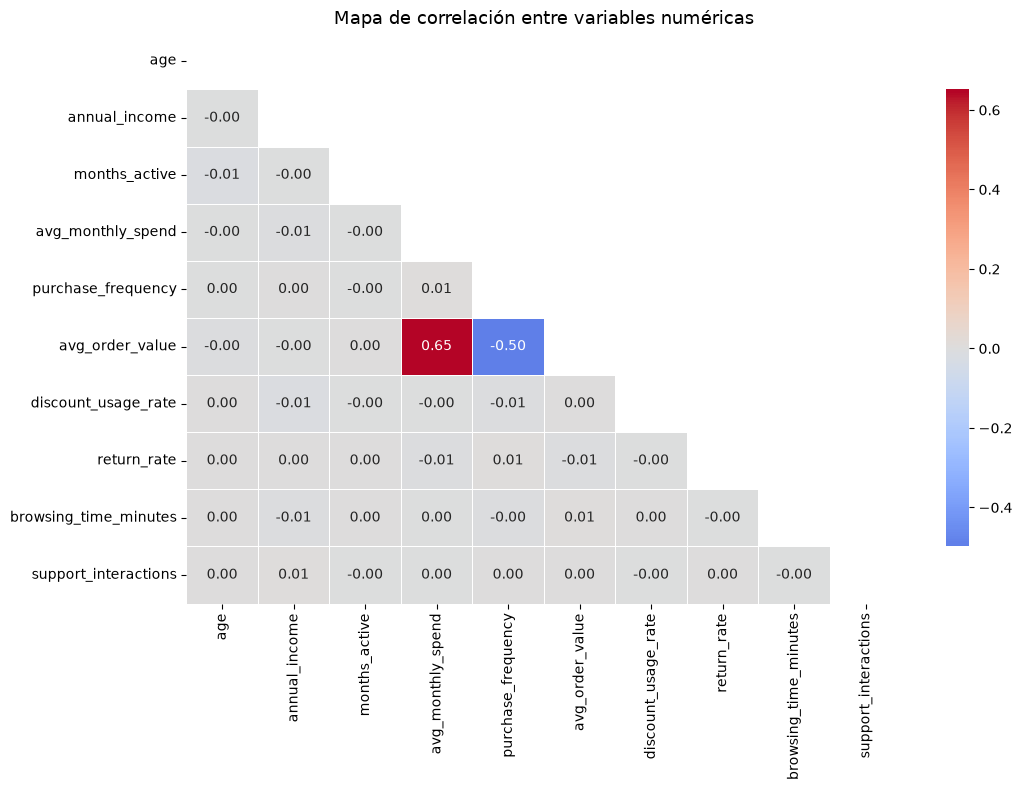

Correlaciones relevantes (|r| > 0.3):
avg_monthly_spend   avg_order_value    0.651687
purchase_frequency  avg_order_value   -0.498097
dtype: float64


In [5]:
# Mapa de correlación
corr = df[num_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Mapa de correlación entre variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

# Correlaciones fuertes (|r| > 0.3)
corr_pairs = corr.unstack()
strong = corr_pairs[(abs(corr_pairs) > 0.3) & (corr_pairs < 1)].sort_values(ascending=False)
print("Correlaciones relevantes (|r| > 0.3):")
print(strong.drop_duplicates())

In [6]:
# PREPROCESAMIENTO


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

df_clean = df.drop(columns=['customer_id']).copy()

# Imputación de valores faltantes ---
num_cols_imp = ['annual_income', 'avg_monthly_spend', 'purchase_frequency',
                'discount_usage_rate', 'return_rate', 'browsing_time_minutes',
                'support_interactions']

# Mediana
imputer = SimpleImputer(strategy='median')
df_clean[num_cols_imp] = imputer.fit_transform(df_clean[num_cols_imp])

print("Valores faltantes tras imputación:")
print(df_clean.isnull().sum())

Valores faltantes tras imputación:
age                      0
annual_income            0
months_active            0
avg_monthly_spend        0
purchase_frequency       0
avg_order_value          0
discount_usage_rate      0
return_rate              0
browsing_time_minutes    0
support_interactions     0
payment_method           0
region                   0
customer_segment         0
dtype: int64


In [7]:
# Codificación de variables categóricas

# One-Hot para payment_method y region
df_clean = pd.get_dummies(df_clean, columns=['payment_method', 'region'], drop_first=True)

# Label Encoding para la variable objetivo
le = LabelEncoder()
df_clean['customer_segment'] = le.fit_transform(df_clean['customer_segment'])

print("Mapeo de clases:", dict(zip(le.classes_, le.transform(le.classes_))))

Mapeo de clases: {'High_Value': np.int64(0), 'Loyal': np.int64(1), 'Occasional': np.int64(2), 'Regular': np.int64(3)}


In [8]:
# Separación de features y target ---
X = df_clean.drop(columns=['customer_segment'])
y = df_clean['customer_segment']

print("Shape de X:", X.shape)
print("Distribución de y:\n", y.value_counts())

Shape de X: (50000, 14)
Distribución de y:
 customer_segment
2    22109
3    13455
1     9163
0     5273
Name: count, dtype: int64


In [9]:
# DIVISIÓN TRAIN/TEST y MANEJO DE DESBALANCEO

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nDistribución en train (antes de SMOTE):")
print(pd.Series(y_train).value_counts())

Train: (40000, 14) | Test: (10000, 14)

Distribución en train (antes de SMOTE):
customer_segment
2    17687
3    10764
1     7331
0     4218
Name: count, dtype: int64


In [10]:
# SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nDistribución en train (después de SMOTE):")
print(pd.Series(y_train_bal).value_counts())
print("\nShape final de train:", X_train_bal.shape)


Distribución en train (después de SMOTE):
customer_segment
1    17687
2    17687
3    17687
0    17687
Name: count, dtype: int64

Shape final de train: (70748, 14)


In [11]:
# Escalado

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)

In [12]:
# 1: REGRESIÓN LOGÍSTICA


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, balanced_accuracy_score,
                              roc_auc_score)
from sklearn.preprocessing import label_binarize

# max_iter alto porque con muchas features puede no converger antes
lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_sc, y_train_bal)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [13]:
# Evaluación
y_pred_lr = lr.predict(X_test_sc)
y_prob_lr  = lr.predict_proba(X_test_sc)

class_names = le.classes_   # ['High_Value', 'Loyal', 'Occasional', 'Regular']

print("REGRESIÓN LOGÍSTICA — Reporte de clasificación")
print("=" * 55)
print(classification_report(y_test, y_pred_lr, target_names=class_names))

# Balanced accuracy: promedia el recall por clase
bal_acc = balanced_accuracy_score(y_test, y_pred_lr)
print(f"Balanced Accuracy: {bal_acc:.4f}")

# AUC-ROC multiclase
y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
auc_lr = roc_auc_score(y_test_bin, y_prob_lr, multi_class='ovr', average='macro')
print(f"AUC-ROC (macro):   {auc_lr:.4f}")

REGRESIÓN LOGÍSTICA — Reporte de clasificación
              precision    recall  f1-score   support

  High_Value       0.60      0.76      0.67      1055
       Loyal       0.60      0.68      0.64      1832
  Occasional       0.77      0.72      0.74      4422
     Regular       0.53      0.49      0.51      2691

    accuracy                           0.65     10000
   macro avg       0.63      0.66      0.64     10000
weighted avg       0.66      0.65      0.65     10000

Balanced Accuracy: 0.6616
AUC-ROC (macro):   0.8628


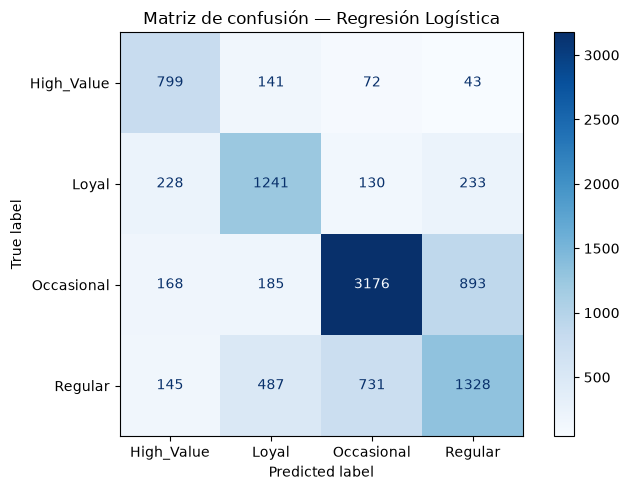

In [14]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=class_names,
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de confusión — Regresión Logística')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy simple:       {acc:.4f}  ")
print(f"Balanced accuracy:     {bal_acc:.4f}  ← promedia recall de cada clase por igual")
print(f"AUC-ROC (macro):       {auc_lr:.4f}  ← mide discriminación entre clases")
print()
print("Métricas por clase a priorizar:")
print("  • Precision: ¿De los que predijo como X, cuántos eran X?")
print("  • Recall:    ¿De los que eran X, cuántos detectó correctamente?")
print("  • F1-score:  Balance entre precision y recall (útil en desbalanceo)")
print()
print("Para este problema, el F1-macro es la métrica principal.")

Accuracy simple:       0.6544  
Balanced accuracy:     0.6616  ← promedia recall de cada clase por igual
AUC-ROC (macro):       0.8628  ← mide discriminación entre clases

Métricas por clase a priorizar:
  • Precision: ¿De los que predijo como X, cuántos eran X?
  • Recall:    ¿De los que eran X, cuántos detectó correctamente?
  • F1-score:  Balance entre precision y recall (útil en desbalanceo)

Para este problema, el F1-macro es la métrica principal.


In [16]:
# 2: RANDOM FOREST — corrección

from sklearn.ensemble import RandomForestClassifier
# ============================================================
# MODELO 2: RANDOM FOREST — con ajuste de hiperparámetros (GridSearchCV)
# ============================================================
from sklearn.model_selection import GridSearchCV

# Grid acotado para que no tarde demasiado (12 combinaciones x 3 folds = 36 entrenamientos)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20, 30],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced',
                                      random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='f1_macro',   # mismo criterio que usamos para evaluar el proyecto
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_bal, y_train_bal)

print("Mejores hiperparámetros encontrados:", grid_rf.best_params_)
print(f"Mejor F1-macro en validación cruzada: {grid_rf.best_score_:.4f}")

rf = grid_rf.best_estimator_   # nos quedamos con el mejor modelo

y_pred_rf = rf.predict(X_test)     # ← X_test, NO X_test_sc
y_prob_rf  = rf.predict_proba(X_test)

print("RANDOM FOREST — Reporte de clasificación")
print("=" * 55)
print(classification_report(y_test, y_pred_rf, target_names=class_names))

bal_acc_rf = balanced_accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(
    label_binarize(y_test, classes=range(len(class_names))),
    y_prob_rf, multi_class='ovr', average='macro'
)
print(f"Balanced Accuracy: {bal_acc_rf:.4f}")
print(f"AUC-ROC (macro):   {auc_rf:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros encontrados: {'max_depth': 30, 'min_samples_leaf': 1, 'n_estimators': 200}
Mejor F1-macro en validación cruzada: 0.8009
RANDOM FOREST — Reporte de clasificación
              precision    recall  f1-score   support

  High_Value       0.82      0.82      0.82      1055
       Loyal       0.86      0.78      0.82      1832
  Occasional       0.78      0.80      0.79      4422
     Regular       0.62      0.64      0.63      2691

    accuracy                           0.75     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.76      0.75      0.75     10000

Balanced Accuracy: 0.7577
AUC-ROC (macro):   0.9123


In [17]:
# Tabla comparativa
from sklearn.metrics import f1_score

resultados = pd.DataFrame({
    'Modelo':            ['Reg. Logística', 'Random Forest'],
    'Accuracy':          [accuracy_score(y_test, y_pred_lr),
                          accuracy_score(y_test, y_pred_rf)],
    'Balanced Accuracy': [bal_acc,    bal_acc_rf],
    'F1-macro':          [f1_score(y_test, y_pred_lr, average='macro'),
                          f1_score(y_test, y_pred_rf, average='macro')],
    'AUC-ROC (macro)':  [auc_lr,     auc_rf]
}).set_index('Modelo').round(4)

print(resultados)

                Accuracy  Balanced Accuracy  F1-macro  AUC-ROC (macro)
Modelo                                                                
Reg. Logística    0.6544             0.6616    0.6406           0.8628
Random Forest     0.7529             0.7577    0.7631           0.9123


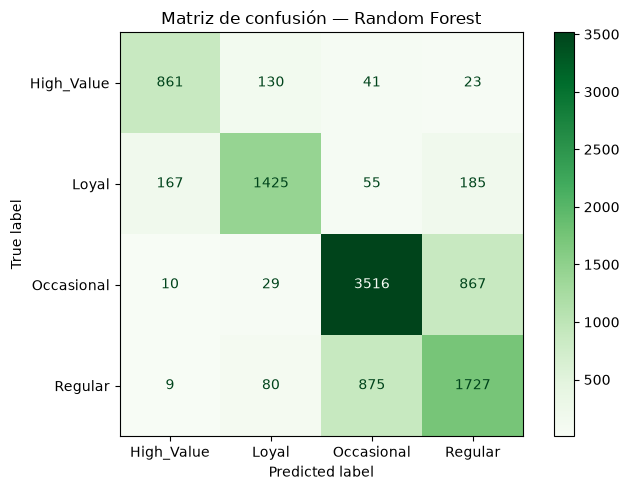

In [18]:
# Matriz de confusión — Random Forest
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=class_names,
    cmap='Greens', ax=ax
)
ax.set_title('Matriz de confusión — Random Forest')
plt.tight_layout()
plt.show()

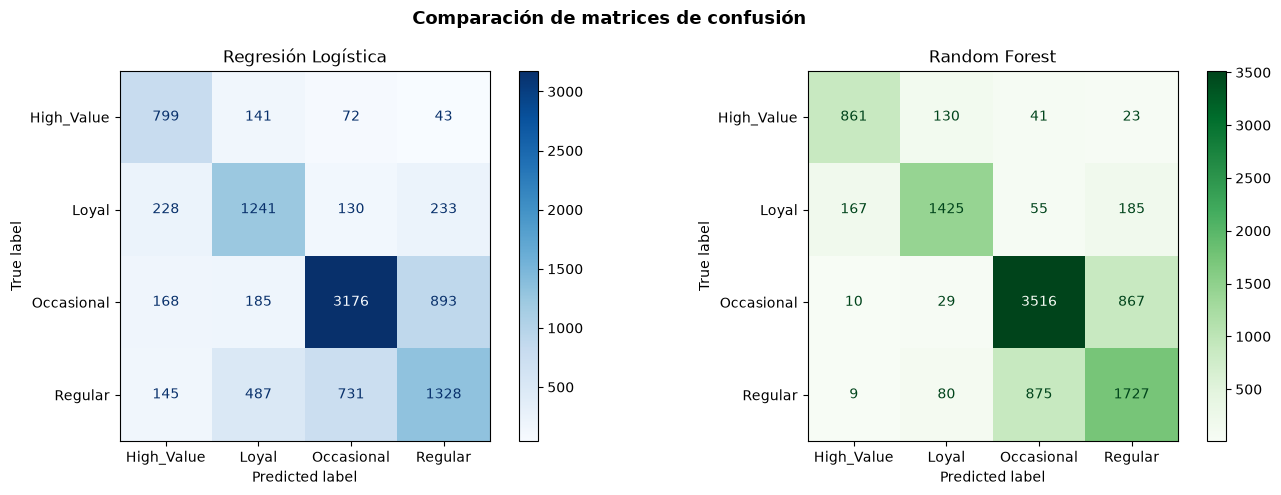

In [19]:
#  Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=class_names,
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Regresión Logística')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=class_names,
    cmap='Greens', ax=axes[1]
)
axes[1].set_title('Random Forest')

plt.suptitle('Comparación de matrices de confusión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

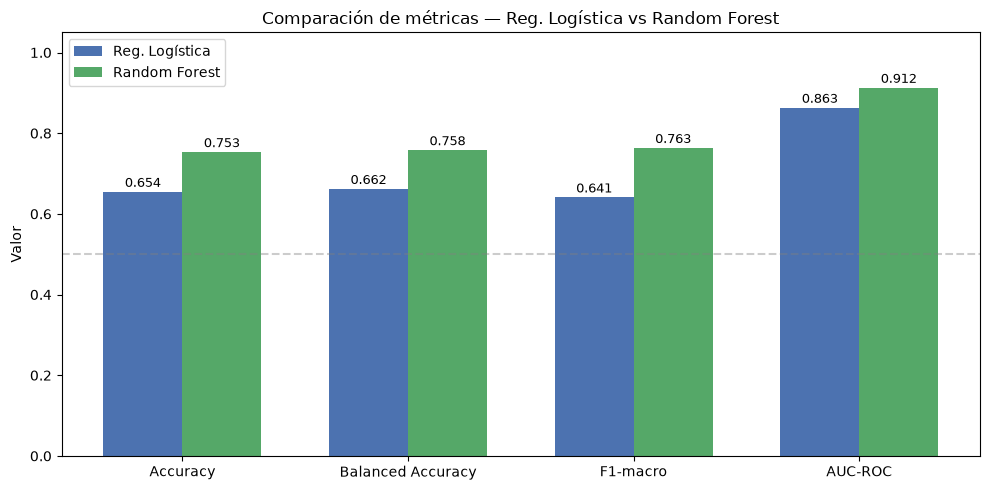

In [20]:
# Comparación de métricas principales
from sklearn.metrics import f1_score

metricas = {
    'Accuracy':          [accuracy_score(y_test, y_pred_lr),
                          accuracy_score(y_test, y_pred_rf)],
    'Balanced Accuracy': [bal_acc, bal_acc_rf],
    'F1-macro':          [f1_score(y_test, y_pred_lr, average='macro'),
                          f1_score(y_test, y_pred_rf, average='macro')],
    'AUC-ROC':           [auc_lr, auc_rf]
}

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, [v[0] for v in metricas.values()],
               width, label='Reg. Logística', color='#4C72B0')
bars2 = ax.bar(x + width/2, [v[1] for v in metricas.values()],
               width, label='Random Forest',  color='#55A868')

# Valores encima de cada barra
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metricas.keys())
ax.set_ylim(0, 1.05)
ax.set_ylabel('Valor')
ax.set_title('Comparación de métricas — Reg. Logística vs Random Forest')
ax.legend()
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, label='baseline 0.5')
plt.tight_layout()
plt.show()

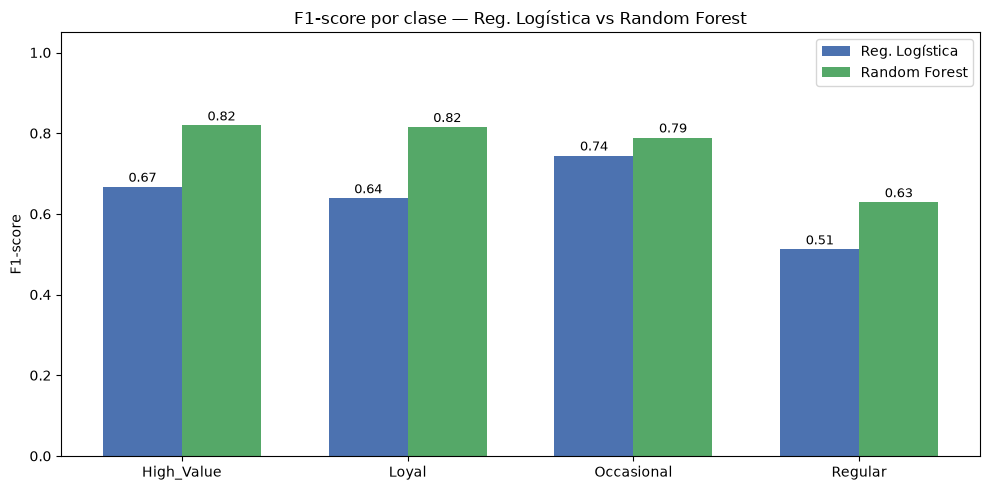

In [21]:
# F1 por clase: comparación
from sklearn.metrics import f1_score

f1_lr = f1_score(y_test, y_pred_lr, average=None)
f1_rf = f1_score(y_test, y_pred_rf, average=None)

x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, f1_lr, width, label='Reg. Logística', color='#4C72B0')
bars2 = ax.bar(x + width/2, f1_rf, width, label='Random Forest',  color='#55A868')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1-score')
ax.set_title('F1-score por clase — Reg. Logística vs Random Forest')
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# MODELO 3: SVM (Support Vector Machine) — con ajuste de hiperparámetros
# Búsqueda y entrenamiento sobre el DATASET COMPLETO (sin muestreo)
# ============================================================
# Cada combinación de C/gamma se evalúa con cv=3 sobre el 100% del train
# balanceado (70,748 filas). Son 4 combinaciones x 3 folds = 12
# entrenamientos, cada uno sobre ~47,165 filas (2/3 de los datos en
# cada fold de validación cruzada). n_jobs=-1 paraleliza estos 12
# entrenamientos entre los núcleos disponibles del procesador.

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import joblib
import time

param_grid_svm = {
    'C': [1, 10],
    'gamma': ['scale', 0.1]
}

n_fits = len(param_grid_svm['C']) * len(param_grid_svm['gamma']) * 3
print("Buscando hiperparámetros sobre el dataset COMPLETO:", X_train_sc.shape[0], "filas")
print(f"Total de entrenamientos a realizar: {n_fits}")

start_grid = time.time()

grid_svm = GridSearchCV(
    estimator=SVC(kernel='rbf', class_weight='balanced', random_state=42),
    param_grid=param_grid_svm,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=3   # nivel alto de detalle para ver el progreso de cada fit
)
grid_svm.fit(X_train_sc, y_train_bal)

elapsed_grid = time.time() - start_grid
print(f"\nBúsqueda terminada en {elapsed_grid/60:.1f} minutos ({elapsed_grid/3600:.2f} horas)")
print("Mejores hiperparámetros encontrados:", grid_svm.best_params_)
print(f"Mejor F1-macro en validación cruzada: {grid_svm.best_score_:.4f}")

# --- GridSearchCV ya reentrena automáticamente (refit=True por defecto)
# el mejor modelo sobre el 100% de X_train_sc, así que no hace falta
# entrenar manualmente otra vez ---
svm = grid_svm.best_estimator_

joblib.dump(svm, "svm_model_full_gridsearch.pkl")
print("Modelo guardado en svm_model_full_gridsearch.pkl")

Buscando hiperparámetros sobre el dataset COMPLETO: 70748 filas
Total de entrenamientos a realizar: 12
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Búsqueda terminada en 23.4 minutos (0.39 horas)
Mejores hiperparámetros encontrados: {'C': 10, 'gamma': 'scale'}
Mejor F1-macro en validación cruzada: 0.7599
Modelo guardado en svm_model_full_gridsearch.pkl


In [25]:
# ============================================================
# REENTRENAMIENTO FINAL — mismo mejor C/gamma encontrados, 
# ahora con probability=True para poder usar predict_proba
# ============================================================
# El GridSearch anterior no necesita repetirse: ya tenemos los
# mejores hiperparámetros en grid_svm.best_params_. Solo hace
# falta un entrenamiento más, con probability=True habilitado.

print("Mejores parámetros (ya encontrados):", grid_svm.best_params_)
print("Reentrenando con probability=True sobre el dataset completo...")

start = time.time()

svm = SVC(kernel='rbf', **grid_svm.best_params_, probability=True,
          class_weight='balanced', random_state=42)
svm.fit(X_train_sc, y_train_bal)

elapsed = time.time() - start
print(f"\nTiempo de entrenamiento: {elapsed/60:.1f} minutos")

joblib.dump(svm, "svm_model_full_gridsearch.pkl")
print("Modelo guardado en svm_model_full_gridsearch.pkl")

Mejores parámetros (ya encontrados): {'C': 10, 'gamma': 'scale'}
Reentrenando con probability=True sobre el dataset completo...


c:\Users\sende\Downloads\Proyectos\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Tiempo de entrenamiento: 55.5 minutos
Modelo guardado en svm_model_full_gridsearch.pkl


In [26]:
# --- Evaluación ---
y_pred_svm = svm.predict(X_test_sc)
y_prob_svm = svm.predict_proba(X_test_sc)

print("=" * 55)
print("SVM (RBF) — Reporte de clasificación")
print("=" * 55)
print(classification_report(y_test, y_pred_svm, target_names=class_names))

bal_acc_svm = balanced_accuracy_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test_bin, y_prob_svm, multi_class='ovr', average='macro')
print(f"Balanced Accuracy: {bal_acc_svm:.4f}")
print(f"AUC-ROC (macro):   {auc_svm:.4f}")

SVM (RBF) — Reporte de clasificación
              precision    recall  f1-score   support

  High_Value       0.77      0.76      0.76      1055
       Loyal       0.74      0.74      0.74      1832
  Occasional       0.78      0.77      0.77      4422
     Regular       0.58      0.60      0.59      2691

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000

Balanced Accuracy: 0.7172
AUC-ROC (macro):   0.8926


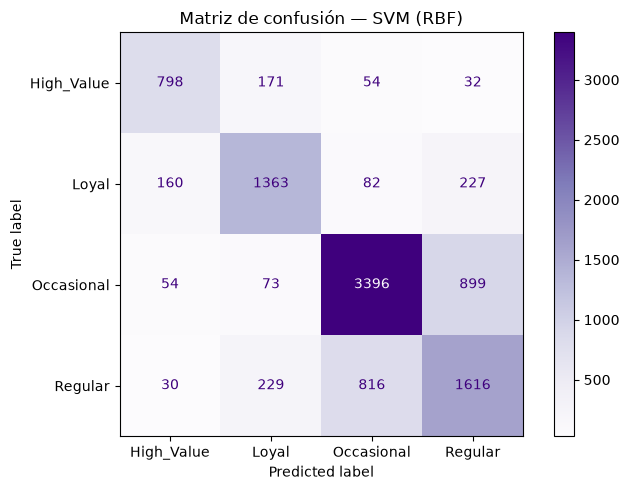

In [27]:
# --- Matriz de confusión — SVM ---
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm,
    display_labels=class_names,
    cmap='Purples', ax=ax
)
ax.set_title('Matriz de confusión — SVM (RBF)')
plt.tight_layout()
plt.show()

In [28]:
# --- Tabla comparativa final (3 modelos) ---
resultados = pd.DataFrame({
    'Modelo':            ['Reg. Logística', 'Random Forest', 'SVM (RBF)'],
    'Accuracy':          [accuracy_score(y_test, y_pred_lr),
                           accuracy_score(y_test, y_pred_rf),
                           accuracy_score(y_test, y_pred_svm)],
    'Balanced Accuracy': [bal_acc, bal_acc_rf, bal_acc_svm],
    'F1-macro':          [f1_score(y_test, y_pred_lr, average='macro'),
                           f1_score(y_test, y_pred_rf, average='macro'),
                           f1_score(y_test, y_pred_svm, average='macro')],
    'AUC-ROC (macro)':   [auc_lr, auc_rf, auc_svm]
}).set_index('Modelo').round(4)

print(resultados)

                Accuracy  Balanced Accuracy  F1-macro  AUC-ROC (macro)
Modelo                                                                
Reg. Logística    0.6544             0.6616    0.6406           0.8628
Random Forest     0.7529             0.7577    0.7631           0.9123
SVM (RBF)         0.7173             0.7172    0.7175           0.8926


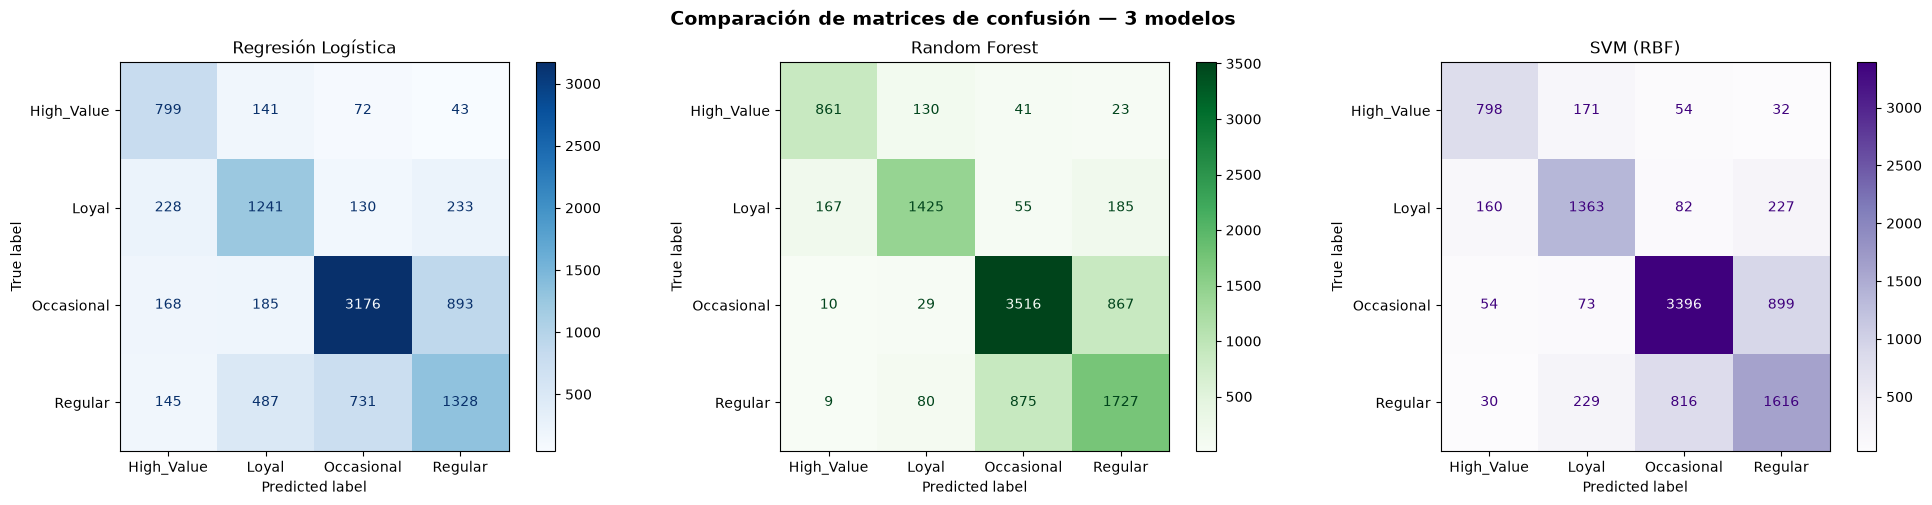

In [29]:
# --- Matrices de confusión comparativas: los 3 modelos ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=class_names,
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Regresión Logística')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=class_names,
    cmap='Greens', ax=axes[1]
)
axes[1].set_title('Random Forest')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm,
    display_labels=class_names,
    cmap='Purples', ax=axes[2]
)
axes[2].set_title('SVM (RBF)')

plt.suptitle('Comparación de matrices de confusión — 3 modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

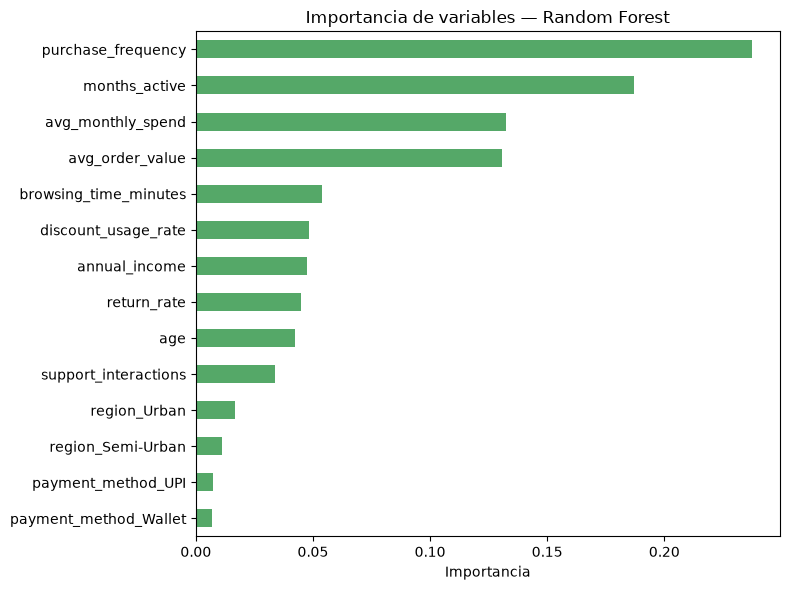

purchase_frequency       0.237508
months_active            0.187093
avg_monthly_spend        0.132326
avg_order_value          0.130715
browsing_time_minutes    0.053665
discount_usage_rate      0.048170
annual_income            0.047568
return_rate              0.044928
age                      0.042344
support_interactions     0.033741
region_Urban             0.016635
region_Semi-Urban        0.011229
payment_method_UPI       0.007148
payment_method_Wallet    0.006929
dtype: float64


In [30]:
# --- Importancia de variables según Random Forest ---
importances = pd.Series(rf.feature_importances_, index=X_train_bal.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='#55A868')
plt.gca().invert_yaxis()
plt.title('Importancia de variables — Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print(importances)

In [31]:
# MODELO EXTRA (curiosidad): GRADIENT BOOSTING
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(random_state=42)
gb.fit(X_train_bal, y_train_bal)   # igual que RF: no necesita escalado

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)

print("GRADIENT BOOSTING — Reporte de clasificación")
print(classification_report(y_test, y_pred_gb, target_names=class_names))

bal_acc_gb = balanced_accuracy_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(
    label_binarize(y_test, classes=range(len(class_names))),
    y_prob_gb, multi_class='ovr', average='macro'
)
print(f"Balanced Accuracy: {bal_acc_gb:.4f}")
print(f"AUC-ROC (macro):   {auc_gb:.4f}")

GRADIENT BOOSTING — Reporte de clasificación
              precision    recall  f1-score   support

  High_Value       0.82      0.81      0.81      1055
       Loyal       0.84      0.78      0.81      1832
  Occasional       0.78      0.82      0.80      4422
     Regular       0.63      0.62      0.63      2691

    accuracy                           0.76     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000

Balanced Accuracy: 0.7572
AUC-ROC (macro):   0.9151


In [32]:
resultados.loc['Gradient Boosting'] = [
    accuracy_score(y_test, y_pred_gb),
    bal_acc_gb,
    f1_score(y_test, y_pred_gb, average='macro'),
    auc_gb
]
print(resultados)

                   Accuracy  Balanced Accuracy  F1-macro  AUC-ROC (macro)
Modelo                                                                   
Reg. Logística       0.6544            0.66160  0.640600         0.862800
Random Forest        0.7529            0.75770  0.763100         0.912300
SVM (RBF)            0.7173            0.71720  0.717500         0.892600
Gradient Boosting    0.7562            0.75716  0.761824         0.915062


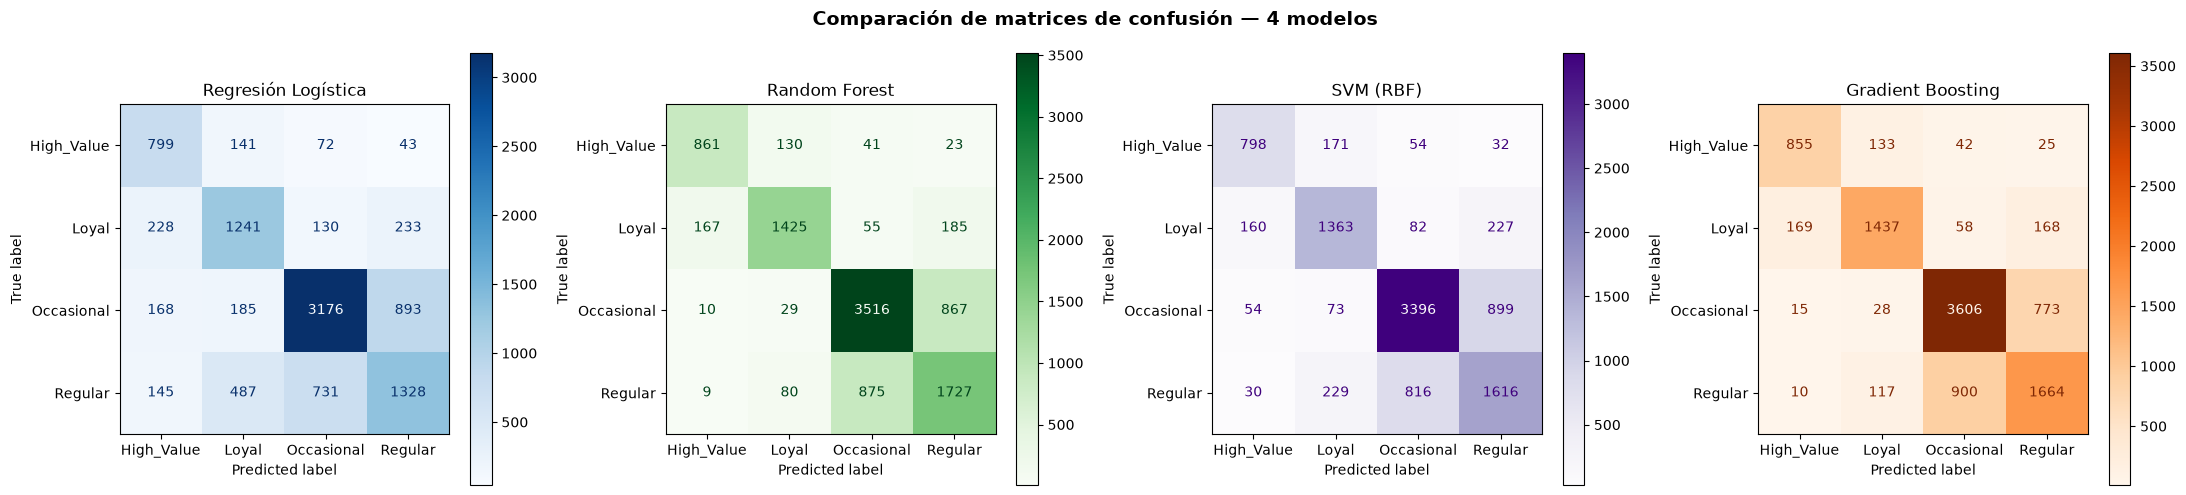

In [33]:
# Matrices de confusión — los 4 modelos
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=class_names, cmap='Blues', ax=axes[0]
)
axes[0].set_title('Regresión Logística')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=class_names, cmap='Greens', ax=axes[1]
)
axes[1].set_title('Random Forest')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm, display_labels=class_names, cmap='Purples', ax=axes[2]
)
axes[2].set_title('SVM (RBF)')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gb, display_labels=class_names, cmap='Oranges', ax=axes[3]
)
axes[3].set_title('Gradient Boosting')

plt.suptitle('Comparación de matrices de confusión — 4 modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

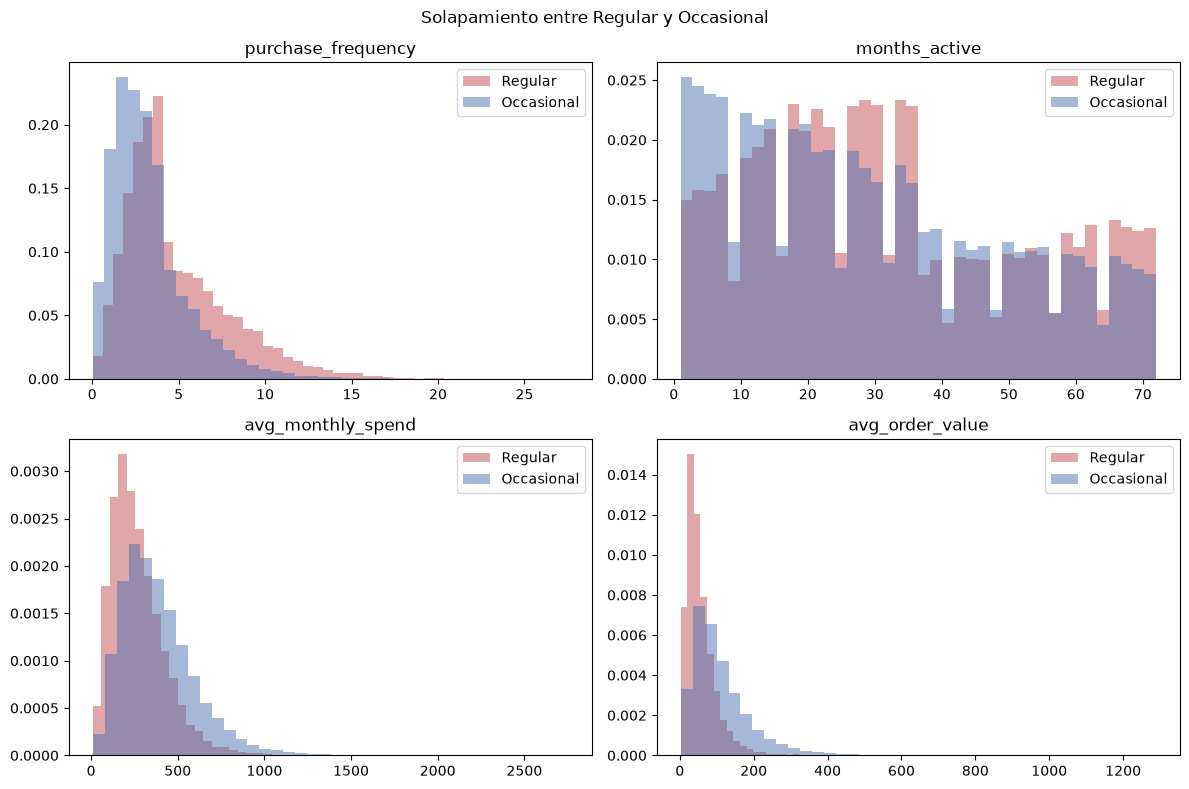

In [34]:
# Comparar distribuciones de Regular vs Occasional en variables clave
top_features = ['purchase_frequency', 'months_active', 'avg_monthly_spend', 'avg_order_value']
subset = df[df['customer_segment'].isin(['Regular', 'Occasional'])]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    for seg, color in zip(['Regular', 'Occasional'], ['#C44E52', '#4C72B0']):
        data = subset[subset['customer_segment'] == seg][col].dropna()
        axes[i].hist(data, bins=40, alpha=0.5, label=seg, density=True, color=color)
    axes[i].set_title(f'{col}')
    axes[i].legend()

plt.suptitle('Solapamiento entre Regular y Occasional')
plt.tight_layout()
plt.show()

In [35]:
def overlap_coefficient(a, b, bins=50):
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
    hist_a, edges = np.histogram(a, bins=bins, range=(lo, hi), density=True)
    hist_b, _ = np.histogram(b, bins=bins, range=(lo, hi), density=True)
    bin_width = edges[1] - edges[0]
    return np.sum(np.minimum(hist_a, hist_b)) * bin_width

print("Solapamiento Regular vs Occasional (0=separados, 1=idénticos):")
for col in top_features:
    a = subset[subset['customer_segment'] == 'Regular'][col].dropna().values
    b = subset[subset['customer_segment'] == 'Occasional'][col].dropna().values
    print(f"  {col}: {overlap_coefficient(a, b):.3f}")

Solapamiento Regular vs Occasional (0=separados, 1=idénticos):
  purchase_frequency: 0.760
  months_active: 0.895
  avg_monthly_spend: 0.749
  avg_order_value: 0.636
